### Installation

In [1]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install or uv pip install
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [2]:
#@title Colab Extra Install { display-mode: "form" }
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
    except: get_numpy = "numpy"; get_pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    get_vllm, get_triton = ("vllm==0.9.2", "triton==3.2.0") if is_t4 else ("vllm==0.10.2", "triton")
    !uv pip install -qqq --upgrade \
        unsloth {get_vllm} {get_numpy} {get_pil} torchvision bitsandbytes xformers
    !uv pip install -qqq {get_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

### Unsloth

In [4]:
from unsloth import FastLanguageModel, is_bfloat16_supported
import torch
max_seq_length = 1024 # Can increase for longer reasoning traces
lora_rank = 32 # Larger rank = smarter, but slower

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Phi-3-mini-4k-instruct",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    load_in_8bit = False, # False for LoRA 16bit
    fast_inference = True, # Enable vLLM fast inference
    full_finetuning = False,
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.6,
    enforce_eager = True,           # Force V0 engine (T4 compatible)
    enable_prefix_caching = False,  # Disable conflicting prefix caching
    disable_log_stats = True,       # Suppress vLLM warnings
    #load_in_fp8 = True, # Float8 RL / GRPO!
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"],
    lora_alpha = 64, # *2 speeds up training
    use_gradient_checkpointing = "unsloth", # Reduces memory usage
    random_state = 3407,
)

INFO 12-06 03:53:41 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 12-06 03:53:41 [vllm_utils.py:732] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.11.6: Fast Mistral patching. Transformers: 4.56.2. vLLM: 0.9.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Standby mode is enabled. Changing `gpu_memory_utilization` to 0.85.
Unsloth: vLLM loading unsloth/phi-3-mini-4k-instruct-bnb-4bit with actual GPU utilization = 84.2%
Unsloth: Your GPU has CUDA compute capability 7.5 with VRAM = 14.74 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 1024. Num Sequences = 48.
Unsloth: vLLM's KV Cache can use up t

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Unsloth: You added custom modules, but Unsloth hasn't optimized for this.
Beware - your finetuning might be noticeably slower!
Unsloth: You added custom modules, but Unsloth hasn't optimized for this.
Beware - your finetuning might be noticeably slower!


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2025.11.6 patched 32 layers with 0 QKV layers, 32 O layers and 0 MLP layers.


# **Data Loading, Cleaning and Formatting for Financial Sentiment Analysis**

In [5]:
from datasets import Dataset, DatasetDict, load_dataset
from sklearn.model_selection import train_test_split
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd

data = pd.read_parquet("hf://datasets/warwickai/financial_phrasebank_mirror/data/train-00000-of-00001.parquet")

In [7]:
data['label'] = data['label'].replace({
    0: 'negative',
    1: 'neutral',
    2: 'positive'
})

In [8]:
data.head()

,sentence,label
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,With the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,positive


In [9]:
unique_labels = data["sentence"].unique()
print(unique_labels)

['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .'
 'Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .'
 'The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .'
 ...
 'Operating profit fell to EUR 35.4 mn from EUR 68.8 mn in 2007 , including vessel sales gain of EUR 12.3 mn .'
 'Net sales of the Paper segment decreased to EUR 221.6 mn in the second quarter of 2009 from EUR 241.1 mn in the second quarter of 2008 , while operating profit excluding non-recurring items rose to EUR 8.0 mn from EUR 7.6 mn .'
 'Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % 

In [10]:
label_counts = data["sentence"].value_counts()
print(label_counts)

sentence
TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sells stake in Morning Digital Design Oy Finnish IT company TJ Group Plc said on Friday 7 April that it had signed an agreement on selling its shares of Morning Digital Design Oy to Edita Oyj .                                                                2
The issuer is solely responsible for the content of this announcement .                                                                                                                                                                                                                                     2
The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .    2
Proha Plc ( Euronext :7327 ) announced today ( 19 May ) that its fully-owned subsidia

In [11]:
# Split the dataset into training and testing sets (80% train, 20% test)
# Stratification ensures class distribution remains consistent
train_df, test_df = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data["label"]
)

In [12]:
# Label counts
train_label_counts = train_df["label"].value_counts()
print(train_label_counts)

label
neutral     2303
positive    1090
negative     483
Name: count, dtype: int64


In [13]:
# Label counts
test_label_counts = test_df["label"].value_counts()
print(test_label_counts)

label
neutral     576
positive    273
negative    121
Name: count, dtype: int64


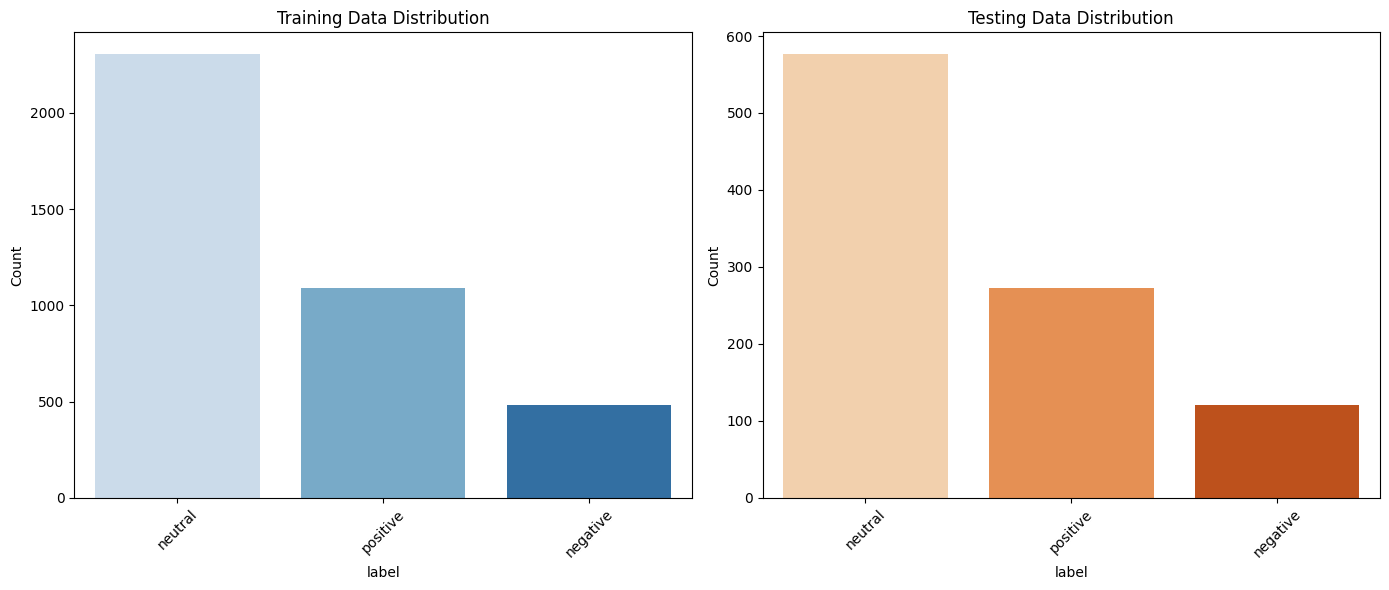

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class distributions
train_counts = train_df["label"].value_counts()
test_counts = test_df["label"].value_counts()

# Create side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot training data distribution
sns.barplot(
    x=train_counts.index,
    y=train_counts.values,
    hue=train_counts.index,  # Assign hue to avoid warning
    dodge=False,
    ax=axes[0],
    palette="Blues",
    legend=False  # Remove legend to avoid AttributeError
)
axes[0].set_title("Training Data Distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Plot testing data distribution
sns.barplot(
    x=test_counts.index,
    y=test_counts.values,
    hue=test_counts.index,
    dodge=False,
    ax=axes[1],
    palette="Oranges",
    legend=False
)
axes[1].set_title("Testing Data Distribution")
axes[1].set_xlabel("label")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

In [15]:

#train_df = train_df.sample(n=100, random_state=42) if len(train_df) > 100 else train_df
#test_df = test_df.sample(n=50, random_state=42) if len(test_df) > 50 else test_df

# Convert the Pandas DataFrames into Hugging Face Dataset objects and store them in a DatasetDict
split_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False)
})

# Print dataset structure to verify the split
print(split_dataset)


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 3876
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 970
    })
})


In [16]:
# Function to truncate inputs exceeding the max_seq_length
def truncate_text(text, max_tokens=1024):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return tokenizer.decode(tokens[:max_tokens])

# Function to format data for GRPO
def format_for_grpo(example):
    # Concise system prompt with a generic, made-up example
    system_prompt = (
      "You are a financial sentiment analyst. "
      "Classify the following financial sentence into ONE of these categories:\n"
      "positive, negative, neutral.\n"
    )
    user_content = truncate_text(example['sentence'], max_tokens=max_seq_length - 100)

    return {
        "prompt": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_content}
        ],
        "answer": example["label"]
    }

# Apply the formatting function to both the training and testing datasets
train_data = split_dataset["train"].map(format_for_grpo, remove_columns=["label", "sentence"])
test_data = split_dataset["test"].map(format_for_grpo, remove_columns=["label", "sentence"])

# Create a new DatasetDict to hold the formatted training and testing data
grpo_dataset = DatasetDict({
    "train": train_data,
    "test": test_data
})

# Print the formatted dataset to verify the structure
print(grpo_dataset)

Map:   0%|          | 0/3876 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'answer'],
        num_rows: 3876
    })
    test: Dataset({
        features: ['prompt', 'answer'],
        num_rows: 970
    })
})


In [17]:
# Print a sample from the training dataset to verify formatting
print("Train Sample:")
print(grpo_dataset["train"][0])

# Print a sample from the testing dataset to verify formatting
print("\nTest Sample:")
print(grpo_dataset["test"][0])

Train Sample:
{'prompt': [{'content': 'You are a financial sentiment analyst. Classify the following financial sentence into ONE of these categories:\npositive, negative, neutral.\n', 'role': 'system'}, {'content': 'The major breweries increased their domestic beer sales by 4.5 per cent last year , to 256.88 million litres from 245.92 million litres in 2004 .', 'role': 'user'}], 'answer': 'positive'}

Test Sample:
{'prompt': [{'content': 'You are a financial sentiment analyst. Classify the following financial sentence into ONE of these categories:\npositive, negative, neutral.\n', 'role': 'system'}, {'content': 'Following the payment made in April , the company has a total of EUR 23.0 million in loans from financial institutions .', 'role': 'user'}], 'answer': 'neutral'}


In [18]:
# Assign the training dataset from the GRPO dataset to a variable
train_data = grpo_dataset["train"]

In [19]:
# show a sample
train_data[1]

{'prompt': [{'content': 'You are a financial sentiment analyst. Classify the following financial sentence into ONE of these categories:\npositive, negative, neutral.\n',
   'role': 'system'},
  {'content': 'CapMan , an asset manager , has EUR 3bn worth of assets under management in the Nordic region .',
   'role': 'user'}],
 'answer': 'neutral'}

In [20]:
test_data = grpo_dataset["test"]

# **Token Count Distribution**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer  # Qwen tokenizer

# Load your dataset
# Example: data = pd.read_csv("your_dataset.csv")Qwen/Qwen2.5-3B-Instruct unsloth
tokenizer = AutoTokenizer.from_pretrained("rd211/Qwen3-0.6B-Instruct")
sns.set_style("whitegrid")

# Ensure Category is categorical
data["label"] = data["label"].astype("category")

token_lengths = data["sentence"].apply(lambda msg: len(tokenizer.tokenize(msg)))
#token_lengths = data["Message"].apply(lambda msg: len(msg.split()))

plt.figure(figsize=(7, 5), dpi=300)
sns.histplot(token_lengths, bins=50, kde=True, color="red", edgecolor="black", linewidth=0.8)
plt.title("Token Count Distribution (Qwen2.5-3B Tokenizer)", fontweight="bold")
plt.xlabel("Token Count", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data["label"] = data["label"].astype("category")

token_lengths = data["sentence"].astype(str).apply(
    lambda msg: len(tokenizer.encode(msg, add_special_tokens=False))
)

plt.figure(figsize=(7, 5), dpi=300)
sns.histplot(token_lengths, bins=50, kde=True, color="blue", edgecolor="black", linewidth=0.8)
plt.title("Token Count Distribution (Plutchik)", fontweight="bold")
plt.xlabel("Token Count", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# **Reward Function Implementation**

In [21]:
current_step = 0  # Track current training step
total_steps = 800  # Your max_steps


from typing import List
import re

def extract_answer(text: str) -> str:
    """Extracts the answer from the given text (category), case insensitive."""
    # Simple regex to match a potential category in the response, case insensitive
    match = re.search(r'\b(positive|negative|neutral)\b', text, re.IGNORECASE)
    return match.group(0).lower() if match else ""  # Return category in lowercase


def correctness_reward_func(prompts, completions, answer, **kwargs) -> List[float]:
    """
    Reward function based on exact class match between prediction and ground truth.
    Assigns a reward (+10) if the response contains the correct emotion category,
    or a penalty (-5 or -10) if it contains an incorrect category.
    NOW WITH CURRICULUM SCALING: Rewards scale from 0.5x to 1.5x during training.
    """
    global current_step  # ← ADD: Declare global

    # Ensure 'answer' is a string, if it's a list, select the first element
    if isinstance(answer, list):
        answer = answer[0]

    # ← ADD: Calculate curriculum scale
    scale = 0.5 + (current_step / total_steps)  # Scales from 0.5 to 1.5

    # Extract content from the completions
    responses = [completion[0]['content'] for completion in completions]
    extracted_responses = [extract_answer(r) for r in responses]

    # List of emotion categories
    categories = ['positive', 'negative', 'neutral']

    rewards = []
    for extracted in extracted_responses:
        # Check if the extracted category matches the correct answer and exists in the categories list
        if extracted == answer.lower() and extracted in categories:
            reward = 10 * scale  # Reward if the category is correct
            print(f"Correct category '{extracted}' found! Reward: {reward:.1f} (scale: {scale:.2f}x)")
        elif extracted not in categories:
            reward = -10 * scale  # ← CHANGE: Add * scale
            print(f"Response '{extracted}' is not a valid category. Reward: {reward:.1f} (scale: {scale:.2f}x)")
        else:
            reward = -5 * scale  # Penalty if no correct category is found
            print(f"Category '{extracted}' is valid but incorrect. Reward: {reward:.1f} (scale: {scale:.2f}x)")

        rewards.append(reward)

    print("*" * 50)
    return rewards

def length_reward_func(prompts, completions, answer, **kwargs) -> List[float]:
    global current_step  # Declare global

    """
    Assigns a reward (+5) for a single-word response, or a penalty (-10) if longer.
    NOW WITH CURRICULUM SCALING!
    """
    # Calculate curriculum scale
    scale = 0.5 + (current_step / total_steps)  # 0.5 to 1.5

    # Extract content from the completions
    responses = [completion[0]['content'] for completion in completions]
    extracted_responses = [extract_answer(r) for r in responses]

    rewards = []
    for extracted in extracted_responses:
        # Count the number of words in the extracted response
        extracted_words = len(extracted.split())
        print(f"Extracted response: {extracted} (words: {extracted_words})")

        # Reward for a single-word answer
        if extracted_words == 1:
            reward = 5 * scale # Reward for a single word
            print(f"Answer is a single word! Reward: {reward:.1f} (scale: {scale:.2f}x)")
        else:
            reward = -10 * scale # Penalty for multiple words
            print(f"Answer has multiple words! Penalty: {reward:.1f} (scale: {scale:.2f}x)")

        rewards.append(reward)

    # INCREMENT STEP AT END
    current_step += 1  # ← THIS IS WHERE IT GOES!

    print("#" * 50)
    return rewards

# **Training Configuration for GRPOTrainer**


In [22]:
from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    # Core settings
    use_vllm = True,
    learning_rate = 5e-6,
    adam_beta1 = 0.9,
    adam_beta2 = 0.99,
    weight_decay = 0.1,#0.001
    warmup_ratio = 0.1,              # 0.05 ← Changed: 5% instead of 10%
    lr_scheduler_type = "cosine",#linear
    optim = "adamw_8bit",
    #bf16 = is_bfloat16_supported(),
    #fp16 = not is_bfloat16_supported(),

    # Training batch settings
    per_device_train_batch_size = 8,
    gradient_accumulation_steps = 1,  # ← Changed: effective batch = 16 Increase to 4 for smoother training 1
    max_grad_norm = 0.1,              # ← Changed: less aggressive 0.1

    # GRPO specific
    num_generations = 8, # Decrease if out of memory
    max_prompt_length = 1024,
    max_completion_length = 50,
    max_steps = 300,
    #num_train_epochs = 1, # Set to 1 for a full training run

    # Logging & saving
    logging_steps = 1,
    save_steps = 50,
    report_to = "none", # Can use Weights & Biases
    output_dir = "outputs",

    # GSPO Configuration (Perfect!)
    #epsilon = 0.2,
    #epsilon_high = 0.28, # one sided
    #delta = 1.5, # two sided
    #importance_sampling_level = "sequence",
    #mask_truncated_completions = False,
    #loss_type = "grpo",
)
    #vllm_sampling_params = vllm_sampling_params,
    #temperature = 1.0,
    # For optional training + evaluation
    #fp16_full_eval = True,
    #per_device_eval_batch_size = 8,
    ##eval_accumulation_steps = 2,
    #eval_strategy = "steps",
    #eval_steps = 50,


#max_prompt_length = maximum_length + 1 # + 1 just in case!
#max_completion_length = max_seq_length - max_prompt_length
#from vllm import SamplingParams
#vllm_sampling_params = SamplingParams(min_p = 0.1, top_p = 1.0, top_k = -1, seed = 3407, stop = [tokenizer.eos_token], include_stop_str_in_output = True,)
    #bf16 = is_bfloat16_supported(),
    #fp16 = not is_bfloat16_supported(),

In [23]:
# For optional training + evaluation
# new_dataset = dataset.train_test_split(test_size = 0.01)

trainer = GRPOTrainer(
    model = model,
    processing_class = tokenizer,
    reward_funcs = [
        length_reward_func,
        correctness_reward_func,
    ],
    args = training_args,
    train_dataset = train_data,
    # For optional training + evaluation
    #eval_dataset = test_data,
)

# Reset step counter before training (optional, if retraining)
current_step = 0

# Start training the model using reinforcement learning
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,876 | Num Epochs = 1 | Total steps = 300
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 17,825,792 of 3,838,905,344 (0.46% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: neutral (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
Extracted response: negative (words: 1)
Answer is a single word! Reward: 2.5 (scale: 0.50x)
##################################################
Correct category 'negative' found! Reward: 5.0 (scale: 0.50x)
Correct category 'negative' found! Reward: 5.0 (scale: 0.50x)
Correct category 'negative' found! R

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / length_reward_func / mean,rewards / length_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
1,-0.000000,6.572656,2.658279,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.500000,0.000000,4.072656,2.658280
2,0.000000,6.589063,2.664909,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.506250,0.000000,4.082812,2.664909
3,0.000000,2.827344,3.910731,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000043,2.512500,0.000000,0.314844,3.910731
4,-0.000000,6.621875,2.678167,4.000000,4.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000027,2.518750,0.000000,4.103125,2.678167
5,0.000000,7.587500,0.000000,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000014,2.525000,0.000000,5.062500,0.000000
6,0.000000,7.606250,0.000000,3.000000,3.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000049,2.531250,0.000000,5.075000,0.000000
7,0.000000,6.671094,2.698055,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000023,2.537500,0.000000,4.133594,2.698054
8,0.000000,7.643750,0.000000,30.000000,30.000000,30.000000,1.000000,0.000000,0.000000,0.000000,0.000016,2.543750,0.000000,5.100000,0.000000
9,0.000000,7.662500,0.000000,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000008,2.550000,0.000000,5.112500,0.000000
10,0.000000,2.876563,3.978659,50.000000,50.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000005,2.556250,0.000000,0.320312,3.978659


Streaming output truncated to the last 5000 lines.
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
Correct category 'neutral' found! Reward: 6.3 (scale: 0.64x)
**************************************************
Extracted response: positive (words: 1)
Answer is a single word! Reward: 3.2 (scale: 0.64x)
Extracted response: positive (words: 1)
Answer is a single word! Reward: 3.2 (scale: 0.64x)
Extracted response: positive (words: 1)
Answer is a single word! Reward: 3.2 (scale: 0.64x)
Extracted response: positive (words: 1)
Answer is a single word! Reward: 3.2 (scale: 0.64x)
Extracted response: positive (words: 1)
Answer is a single word! Reward: 3.2 (scale: 0.64x)
Extracted r

TrainOutput(global_step=300, training_loss=0.0004193350611659551, metrics={'train_runtime': 1995.5715, 'train_samples_per_second': 1.203, 'train_steps_per_second': 0.15, 'total_flos': 0.0, 'train_loss': 0.0004193350611659551})

<a name="Inference"></a>
# **Inference**
Now let's try the model we just trained! First, let's first try the model without any GRPO trained:

In [30]:
from vllm import SamplingParams

# Define the system prompt for message classification
system_prompt = (
      "You are a financial sentiment analyst. "
      "Classify the following financial sentence into ONE of these categories:\n"
      "positive, negative, neutral.\n"
    )

# Construct the input text using the tokenizer's chat template
text = tokenizer.apply_chat_template(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Following the payment made in April , the company has a total of EUR 23.0 million in loans from financial institutions."},  # User's input message
    ],
    tokenize=False,
    add_generation_prompt=True,
)

# Define sampling parameters for text generation
sampling_params = SamplingParams(
    temperature=0.0,  # Set temperature to 0 for deterministic output
    top_p=0.95,  # Use nucleus sampling with a probability threshold of 0.95
    max_tokens=1024,  # Set the maximum number of tokens in the output
)

# Generate the model's response using fast inference
output = model.fast_generate(
    [text],  # Provide input text for generation
    sampling_params=sampling_params,  # Apply defined sampling parameters
    lora_request=None,  # No LoRA adaptation in this case
)[0].outputs[0].text  # Extract the generated text output

# Display the model's response
output


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

TypeError: LoRAModel.from_local_checkpoint() got an unexpected keyword argument 'lora_path'

In [28]:
# And now with the LoRA we just trained with GRPO - we first save the LoRA first!
model.save_lora("grpo_saved_lora")

In [31]:
#Now we load the LoRA and test:
from vllm import SamplingParams

# Define the system instruction for message classification
system_prompt = (
      "You are a financial sentiment analyst. "
      "Classify the following financial sentence into ONE of these categories:\n"
      "positive, negative, neutral.\n"
    )

# Format the input text using the tokenizer's chat template
text = tokenizer.apply_chat_template(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": "Following the payment made in April , the company has a total of EUR 23.0 million in loans from financial institutions."},  # User's input message
    ],
    tokenize=False,  # Keep the input as a string without tokenization
    add_generation_prompt=True,  # Append a prompt for generating the model's response
)

# Define sampling parameters for text generation
sampling_params = SamplingParams(
    temperature=0.0,  # Introduce randomness in output generation
    top_p=0.95,  # Use nucleus sampling with a probability threshold of 0.95
    max_tokens=1024,  # Limit the output to a maximum of 1024 tokens
)

# Load the LoRA adapter for fine-tuned generation
lora_adapter = model.load_lora("grpo_saved_lora")

# Generate the model's response using fast inference with LoRA adaptation
output = model.fast_generate(
    text,  # Provide formatted input text
    sampling_params=sampling_params,  # Apply defined sampling parameters
    lora_request=lora_adapter,  # Use the loaded LoRA model
)[0].outputs[0].text  # Extract the generated text output

# Display the generated response
output

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

TypeError: LoRAModel.from_local_checkpoint() got an unexpected keyword argument 'lora_path'

# **Evaluation**

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
import re
import difflib
import numpy as np
import random

In [33]:
# Extract true answers and corresponding messages from the test dataset
test_answers = [answer.lower() for answer in grpo_dataset["test"]["answer"]]  # Ground truth classifications
test_messages = [entry["prompt"][1]["content"] for entry in grpo_dataset["test"]]  # Extract user messages

In [34]:
# Select a sample index to inspect
samp = 6

# Print the ground truth classification for the selected sample
print("True Classification:", test_answers[samp])

# Print the corresponding user message
print("User Message:", test_messages[samp])

True Classification: positive
User Message: The subscriptions increase Cargotec 's share capital by 36,780 euros .


In [35]:
sns.set_style("whitegrid")
import random
import re
import difflib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def extract_classification(output, true_answer, categories=None):
    """
    Extracts the predicted category from the output text.
    If no valid category is found, returns a wrong one (not equal to true_answer).

    Args:
        output (str): Text generated by the model.
        true_answer (str): The correct label for the input.
        categories (list): List of valid category strings.

    Returns:
        str: Extracted or fallback category.
    """
    if categories is None:
        categories = ["positive", "negative", "neutral"]

    # Extract all words in lowercase
    words = re.findall(r"\b\w+\b", output.lower())

    # Look for a close match to the categories in reverse order (latest words first)
    for word in reversed(words):
        match = difflib.get_close_matches(word, categories, n=1, cutoff=0.7)
        if match:
            return match[0]

    # If no category matched, return a wrong one
    wrong_choices = [cat for cat in categories if cat != true_answer]
    return random.choice(wrong_choices)

def count_words(text):
    """Counts the number of words in the given text."""
    return len(re.findall(r"\b\w+\b", text))

def evaluate_model(true_labels, predicted_labels):
    """
    Computes and displays evaluation metrics for classification.

    Args:
        true_labels (list): Ground truth categories.
        predicted_labels (list): Model-predicted categories.
    """
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average="macro")
    recall = recall_score(true_labels, predicted_labels, average="macro")
    f1 = f1_score(true_labels, predicted_labels, average="macro")
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=sorted(set(true_labels + predicted_labels)))
    class_report = classification_report(true_labels, predicted_labels)

    # Output results
    print("Model Evaluation Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1-score (macro): {f1:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)

    cm = np.array(conf_matrix)  # your confusion matrix
    n_classes = cm.shape[0]
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    for i in range(n_classes):
        print(f"Class {i}: TP={TP[i]}, FP={FP[i]}, FN={FN[i]}, TN={TN[i]}")

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6), dpi=300)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(set(true_labels + predicted_labels)),
                yticklabels=sorted(set(true_labels + predicted_labels)))
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

def calculate_accuracy_length(output_word_counts):
    """
    Measures how many of the responses are a single word.

    Args:
        output_word_counts (list[int]): Word count of each model output.

    Returns:
        float: Ratio of single-word responses.
    """
    single_word_responses = sum(1 for count in output_word_counts if count == 1)
    total_samples = len(output_word_counts)
    return single_word_responses / total_samples if total_samples > 0 else 0

def plot_per_class_metrics(true_labels, predicted_labels, class_names):
    report = classification_report(true_labels, predicted_labels, output_dict=True, labels=class_names)
    df = pd.DataFrame(report).T

    # Remove "accuracy", "macro avg", etc.
    df = df.loc[class_names]

    df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(12, 6))
    plt.title("Per-Class Evaluation Metrics")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(axis='y')
    plt.legend(loc='lower right')
    plt.show()

# **Core Imports**

In [36]:
import pandas as pd
from sklearn.metrics import classification_report

def get_per_class_metrics_table(true_labels, predicted_labels, class_names):
    # Generate classification report
    report = classification_report(true_labels, predicted_labels, output_dict=True, target_names=class_names)
    df = pd.DataFrame(report).T

    # Keep only classes
    df = df.loc[class_names + ["accuracy", "macro avg", "weighted avg"],
                ["precision", "recall", "f1-score"]]
    # Round for neatness
    df = df.round(4)

    return df

In [37]:
# === Core Imports ===
import numpy as np
import pandas as pd
import re, difflib, random
import matplotlib.pyplot as plt
import seaborn as sns

from typing import List, Optional, Tuple
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")

# =========================================================
# 1) Evaluation Helpers (labels, extraction, length)
# =========================================================

DEFAULT_CLASSES = ["positive", "negative", "neutral"]

def extract_classification(output: str,
                           true_answer: str,
                           categories: Optional[List[str]] = None,
                           allow_fallback_wrong: bool = False) -> str:
    """
    Extract the predicted class from model output using fuzzy matching.
    If no valid category is found:
      - if allow_fallback_wrong=True, return a random wrong class
      - else return 'invalid'
    """
    if categories is None:
        categories = DEFAULT_CLASSES

    words = re.findall(r"\b\w+\b", output.lower())
    for word in reversed(words):
        match = difflib.get_close_matches(word, categories, n=1, cutoff=0.7)
        if match:
            return match[0]

    if allow_fallback_wrong:
        wrong_choices = [c for c in categories if c != true_answer]
        return random.choice(wrong_choices) if wrong_choices else "invalid"
    return "invalid"

def count_words(text: str) -> int:
    return len(re.findall(r"\b\w+\b", text))

def single_word_ratio(output_word_counts: List[int]) -> float:
    single = sum(1 for n in output_word_counts if n == 1)
    total = len(output_word_counts)
    return single / total if total else 0.0

# =========================================================
# 2) Metrics + Tables
# =========================================================

def compute_metrics(true_labels: List[str],
                    predicted_labels: List[str],
                    class_names: List[str]) -> dict:
    """Return scalar metrics and a per-class report DataFrame."""
    acc = accuracy_score(true_labels, predicted_labels)
    prec = precision_score(true_labels, predicted_labels, average="macro", zero_division=0)
    rec = recall_score(true_labels, predicted_labels, average="macro", zero_division=0)
    f1 = f1_score(true_labels, predicted_labels, average="macro", zero_division=0)

    report = classification_report(true_labels, predicted_labels,
                                   labels=class_names, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).T
    per_class_df = df_report.loc[class_names][["precision", "recall", "f1-score", "support"]]

    return {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "per_class_df": per_class_df
    }

def export_tables(per_class_df: pd.DataFrame,
                  csv_path: Optional[str] = None,
                  latex_path: Optional[str] = None):
    """Export per-class table to CSV/LaTeX (IEEE-ready)."""
    if csv_path:
        per_class_df.to_csv(csv_path, float_format="%.4f")
    if latex_path:
        # IEEE-friendly LaTeX table (no index name, 4 decimals)
        with open(latex_path, "w", encoding="utf-8") as f:
            f.write(per_class_df.to_latex(float_format="%.4f",
                                          index=True,
                                          caption="Per-class metrics",
                                          label="tab:per_class_metrics"))

# =========================================================
# 3) Plots (all 300 dpi on-screen; optional savepath)
# =========================================================

def _finalize(show: bool, savepath: Optional[str]):
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

def plot_confusion(true_labels: List[str],
                   predicted_labels: List[str],
                   class_names: List[str],
                   normalize: Optional[str] = None,  # None, 'true', 'pred', 'all'
                   title: str = "Confusion Matrix",
                   show: bool = True,
                   savepath: Optional[str] = None):
    """
    normalize: None, 'true' (row), 'pred' (col), 'all' (global)
    """
    plt.figure(figsize=(8, 6), dpi=300)
    cm = confusion_matrix(true_labels, predicted_labels, labels=class_names, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    _finalize(show, savepath)

def plot_per_class_bars(per_class_df: pd.DataFrame,
                        title: str = "Per-Class Precision/Recall/F1",
                        show: bool = True,
                        savepath: Optional[str] = None):
    plt.figure(figsize=(12, 6), dpi=300)
    per_class_df[["precision", "recall", "f1-score"]].plot(kind="bar")
    plt.title(title)
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.legend(loc="lower right")
    _finalize(show, savepath)

def plot_support_distribution(per_class_df: pd.DataFrame,
                              title: str = "Class Support (Test Set)",
                              show: bool = True,
                              savepath: Optional[str] = None):
    plt.figure(figsize=(10, 4), dpi=300)
    per_class_df["support"].plot(kind="bar")
    plt.title(title)
    plt.ylabel("Number of samples")
    plt.grid(axis="y")
    _finalize(show, savepath)

def plot_length_histogram(lengths: List[int],
                          bins: int = 10,
                          title: str = "Output Length Distribution",
                          show: bool = True,
                          savepath: Optional[str] = None):
    plt.figure(figsize=(8, 4), dpi=300)
    plt.hist(lengths, bins=bins)
    plt.title(title)
    plt.xlabel("Words in output")
    plt.ylabel("Count")
    plt.grid(axis="y")
    _finalize(show, savepath)

def compute_top_confusions(true_labels: List[str],
                           predicted_labels: List[str],
                           class_names: List[str],
                           topk: int = 10) -> pd.DataFrame:
    """
    Return top-k (true->pred) error pairs by count (excluding correct pairs).
    """
    cm = confusion_matrix(true_labels, predicted_labels, labels=class_names)
    errors = []
    for i, true_c in enumerate(class_names):
        for j, pred_c in enumerate(class_names):
            if i == j:
                continue
            count = cm[i, j]
            if count > 0:
                errors.append((true_c, pred_c, count))
    errors.sort(key=lambda x: x[2], reverse=True)
    df = pd.DataFrame(errors, columns=["true", "pred", "count"])
    return df.head(topk)

def plot_top_confusions(df_err: pd.DataFrame,
                        title: str = "Top Confusions (True → Pred)",
                        show: bool = True,
                        savepath: Optional[str] = None):
    if df_err.empty:
        print("No confusions to plot.")
        return
    plt.figure(figsize=(10, 5), dpi=300)
    labels = [f"{t} → {p}" for t, p in zip(df_err["true"], df_err["pred"])]
    plt.bar(labels, df_err["count"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(axis="y")
    _finalize(show, savepath)

# =========================================================
# 4) End-to-end Example (drop-in with your variables)
# =========================================================
# Assumes you already have:
#   true labels:     test_answers
#   predicted labels: predicted_labels_grpo
#   output lengths:  output_word_counts_grpo
#   class order:     class_names = DEFAULT_CLASSES (or your custom order)

def full_analysis_pipeline(true_labels: List[str],
                           predicted_labels: List[str],
                           output_lengths: Optional[List[int]],
                           class_names: List[str]):
    # --- Metrics ---
    m = compute_metrics(true_labels, predicted_labels, class_names)
    print("=== Global Metrics ===")
    print(f"Accuracy       : {m['accuracy']:.4f}")
    print(f"Precision (macro): {m['precision_macro']:.4f}")
    print(f"Recall (macro)   : {m['recall_macro']:.4f}")
    print(f"F1 (macro)       : {m['f1_macro']:.4f}")
    print("\n=== Per-Class Metrics ===")
    print(m["per_class_df"])

    # Optional exports (uncomment to save)
    # export_tables(m["per_class_df"],
    #               csv_path="per_class_metrics.csv",
    #               latex_path="per_class_metrics.tex")

    # --- Plots (all 300 dpi on-screen) ---
    plot_confusion(true_labels, predicted_labels, class_names,
                   normalize=None, title="Confusion Matrix (Counts)")
    plot_confusion(true_labels, predicted_labels, class_names,
                   normalize="true", title="Confusion Matrix (Row-Normalized)")

    plot_per_class_bars(m["per_class_df"],
                        title="Per-Class Precision/Recall/F1")
    plot_support_distribution(m["per_class_df"],
                              title="Class Support (Test Set)")

    if output_lengths is not None:
        ratio = single_word_ratio(output_lengths)
        print(f"\nSingle-word compliance: {ratio:.2%}")
        plot_length_histogram(output_lengths, bins=10,
                              title="Output Length Distribution")

    # --- Error Analysis ---
    df_err = compute_top_confusions(true_labels, predicted_labels, class_names, topk=10)
    print("\n=== Top Confusions (True → Pred) ===")
    print(df_err)
    plot_top_confusions(df_err, title="Top Confusions (True → Pred)")

# **After GRPO**

In [38]:
import re
from vllm import SamplingParams
import difflib

# Define a fixed system prompt for message classification
system_prompt = (
      "You are a financial sentiment analyst. "
      "Classify the following financial sentence into ONE of these categories:\n"
      "positive, negative, neutral.\n"
    )
categories = ["positive", "negative", "neutral"]
# List to store predicted labels after applying GRPO
predicted_labels_grpo = []

# List to store word counts of model outputs
output_word_counts_grpo = []

# Define sampling parameters for text generation
sampling_params = SamplingParams(
    temperature=0.0,  # Set temperature to 0 for deterministic output
    top_p=0.95,  # Use nucleus sampling with a probability threshold of 0.95
    max_tokens=1024,  # Set the maximum number of tokens in the output
)

count = 1
# Process each test message through the model and extract classification
for message, true_answer in zip(test_messages, test_answers):
    # Prepare input text using the tokenizer
    text = tokenizer.apply_chat_template([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": message},
    ], tokenize=False, add_generation_prompt=True)

    # Run the model using the saved GRPO LoRA
    output = model.fast_generate(
        text,
        sampling_params=sampling_params,
        lora_request=model.load_lora("grpo_saved_lora"),  # Load fine-tuned LoRA model
    )[0].outputs[0].text

    print(f"the sample number: {count}")
    count+= 1

    # Store word count of the model output
    output_word_counts_grpo.append(count_words(output))

    # Extract classification from model output and store in the list
    predicted_labels_grpo.append(extract_classification(output, true_answer))

# Print the first 10 predicted classifications
print(predicted_labels_grpo[:10])
# Print the first 10 word counts of model outputs
print(output_word_counts_grpo[:10])

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/6 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

TypeError: LoRAModel.from_local_checkpoint() got an unexpected keyword argument 'lora_path'

In [ ]:
# Calculate and print accuracy
accuracy = calculate_accuracy_length(output_word_counts_grpo)
print(f"Model accuracy based on single-word responses: {accuracy:.2%}")

In [ ]:
# Evaluate the model after applying GRPO
print("Metrics with GRPO:")
evaluate_model(test_answers, predicted_labels_grpo)

In [ ]:
class_names = ["positive", "negative", "neutral"]
plot_per_class_metrics(test_answers, predicted_labels_grpo, class_names)

In [ ]:
results_table = get_per_class_metrics_table(test_answers, predicted_labels_grpo, class_names)
print(results_table)

In [ ]:
full_analysis_pipeline(
    true_labels=test_answers,
    predicted_labels=predicted_labels_grpo,
    output_lengths=output_word_counts_grpo,
    class_names=class_names
)

# **Before GRPO**

In [ ]:
system_prompt = (
      "You are a financial sentiment analyst. "
      "Classify the following financial sentence into ONE of these categories:\n"
      "positive, negative, neutral.\n"
    )
categories = ["positive", "negative", "neutral"]
# List to store predicted classifications
predicted_labels = []
# List to store word counts of model outputs
output_word_counts = []

# Define sampling parameters for text generation
sampling_params = SamplingParams(
    temperature=0.0,  # Set temperature to 0 for deterministic output
    top_p=0.95,  # Use nucleus sampling with a probability threshold of 0.95
    max_tokens=1024,  # Set the maximum number of tokens in the output
)

count = 1
# Process each test message through the model and extract classification
for message, true_answer in zip(test_messages, test_answers):
    # Prepare input text using the tokenizer
    text = tokenizer.apply_chat_template([
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": message},
    ], tokenize=False, add_generation_prompt=True)

    # Generate model output without LoRA fine-tuning
    output = model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,  # No LoRA applied
    )[0].outputs[0].text

    print(f"the sample number: {count}")
    count+= 1

    # Store word count of the model output
    output_word_counts.append(count_words(output))

    # Extract classification from model output and store in the list
    predicted_labels.append(extract_classification(output, true_answer))

# Print the first 10 predicted classifications
print(predicted_labels[:10])
# Print the first 10 word counts of model outputs
print(output_word_counts[:10])

In [ ]:
# Calculate and print accuracy
accuracy = calculate_accuracy_length(output_word_counts)
print(f"Model accuracy based on single-word responses: {accuracy:.2%}")

In [ ]:
# Evaluate the model before applying GRPO
print("Metrics without GRPO:")
evaluate_model(test_answers, predicted_labels)

In [ ]:
class_names = ["positive", "negative", "neutral"]
plot_per_class_metrics(test_answers, predicted_labels, class_names)

In [ ]:
results_table = get_per_class_metrics_table(test_answers, predicted_labels, class_names)
print(results_table)

In [ ]:
full_analysis_pipeline(
    true_labels=test_answers,
    predicted_labels=predicted_labels,
    output_lengths=output_word_counts,
    class_names=class_names
)